11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - kl_loss: 3.4379 - loss: 173.4447 - reconstruction_loss: 170.0069
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 2.9379 - loss: 164.2155 - reconstruction_loss: 161.2776
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 3.0293 - loss: 165.2363 - reconstruction_loss: 162.2070
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 3.4501 - loss: 159.4576 - reconstruction_loss: 156.0075
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: 3.1197 - loss: 164.6894 - reconstruction_loss: 161.5696
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 3.1229 - loss: 166.0353 - reconstruction_loss: 162.9125
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 3.2153 - loss: 169.8626 - reconstruction_loss: 166.6473
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 3.2609 - loss: 162.2016 - reconstruction_los

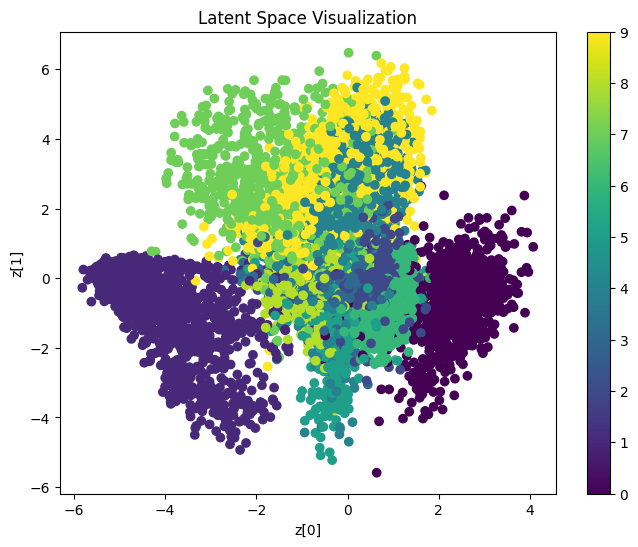

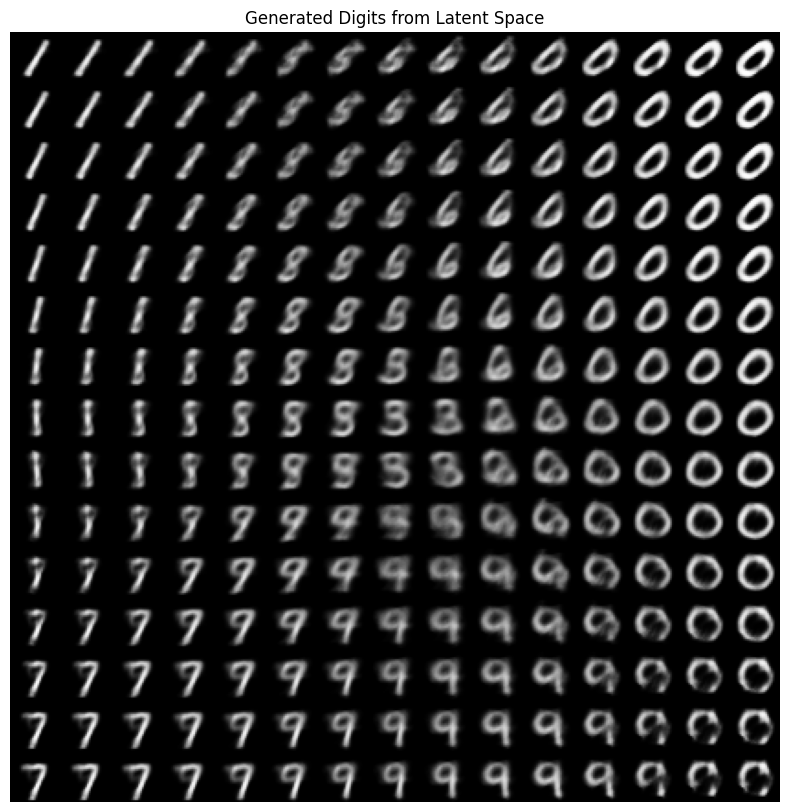

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# 🔹 1. Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.
x_test  = x_test.astype("float32") / 255.

# Flatten
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# 🔹 2. Sampling Layer (Reparameterization Trick)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 2  # for visualization

# 🔹 3. Encoder
encoder_inputs = layers.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 🔹 4. Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# 🔹 5. VAE Model
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data, reconstruction)
            ) * 784

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
        }

# 🔹 6. Compile & Train
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

vae.fit(x_train, epochs=10, batch_size=128)

# 🔹 7. Latent Space Visualization
z_mean_test, _, _ = encoder.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test)
plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("Latent Space Visualization")
plt.show()

# 🔹 8. Generate Images from Latent Space
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(28, 28)

        figure[
            i * digit_size:(i + 1) * digit_size,
            j * digit_size:(j + 1) * digit_size
        ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Generated Digits from Latent Space")
plt.show()